# RFM Customer Segmentation
Segmenting Olist customers by Recency, Frequency, and Monetary value to identify high-value and at-risk customers.

In [1]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

client = bigquery.Client(project='dataai-project-0')

E0000 00:00:1780300619.840521  153359 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1780300619.840665  153359 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1780300619.840676  153359 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1780300619.840682  153359 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1780300619.840687  153359 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.


## EDA — Sanity Checks

In [2]:
eda = client.query("""
    SELECT
        COUNT(DISTINCT customer_id)             AS unique_customers,
        MIN(order_date)                         AS earliest_order,
        MAX(order_date)                         AS latest_order,
        ROUND(AVG(total_amount), 2)             AS avg_item_value,
        ROUND(SUM(total_amount), 2)             AS total_revenue
    FROM `dataai-project-0.gold.fact_orders`
""").to_dataframe()

print(eda.to_string(index=False))

/home/seanwong/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


 unique_customers earliest_order latest_order  avg_item_value  total_revenue
            98666     2016-09-04   2018-09-03          140.64    15843553.24


## Step 1 — Calculate RFM Values

In [3]:
rfm = client.query("""
    SELECT
        customer_id,
        DATE_DIFF(DATE '2018-10-01', MAX(order_date), DAY)  AS recency,
        COUNT(DISTINCT order_id)                             AS frequency,
        ROUND(SUM(total_amount), 2)                          AS monetary
    FROM `dataai-project-0.gold.fact_orders`
    GROUP BY 1
""").to_dataframe()

print(f"Customers analysed: {len(rfm):,}")
rfm.describe().round(2)

/home/seanwong/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Customers analysed: 98,666


,recency,frequency,monetary
count,98666.0,98666.0,98666.00
mean,273.72,1.0,160.58
std,153.39,0.0,220.47
min,28.0,1.0,9.59
25%,150.0,1.0,61.98
50%,255.0,1.0,105.29
75%,384.0,1.0,176.87
max,757.0,1.0,13664.08


## Step 2 — Score Each Dimension (1–5)

In [4]:
# Recency: lower days = better = higher score
rfm['r_score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency and Monetary: higher = better = higher score
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']
rfm.head()

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score
0,6059aa1741543dc3611f547d6c21917b,282,1,140.03,3,1,4,8
1,0b6c2ee27dbe0bcbffd424f2ddedd222,250,1,149.64,3,1,4,8
2,fc3d1daec319d62d49bfb5e1f83123e9,442,1,196.17,1,1,4,6
3,5547962397f3a6e2d13ff5cd1feb1bdf,376,1,71.95,2,1,2,5
4,07e6f1ea396eea8aa95d0c1cf5a8d364,254,1,55.18,3,1,2,6


## Step 3 — Assign Segments

In [5]:
def assign_segment(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal'
    elif r >= 3 and f <= 2:
        return 'Promising'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    else:
        return 'Lost'

rfm['segment'] = rfm.apply(assign_segment, axis=1)
rfm['segment'].value_counts()

segment
Promising    23360
At Risk      23160
Loyal        19139
Lost         18386
Champions    14621
Name: count, dtype: int64

## Key Metrics — Segment Profiles

In [6]:
segment_profile = rfm.groupby('segment').agg(
    customers=('customer_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).round(2).sort_values('total_revenue', ascending=False)

segment_profile['% customers'] = (segment_profile['customers'] / len(rfm) * 100).round(1)
segment_profile['% revenue'] = (segment_profile['total_revenue'] / rfm['monetary'].sum() * 100).round(1)

print(segment_profile.to_string())

           customers  avg_recency  avg_frequency  avg_monetary  total_revenue  % customers  % revenue
segment                                                                                              
At Risk        23160       432.03            1.0        230.55     5339559.87         23.5       33.7
Champions      14621       126.04            1.0        305.56     4467544.25         14.8       28.2
Loyal          19139       201.54            1.0        178.14     3409331.01         19.4       21.5
Promising      23360       169.82            1.0         61.85     1444827.53         23.7        9.1
Lost           18386       398.87            1.0         64.30     1182290.58         18.6        7.5


## Visualisation

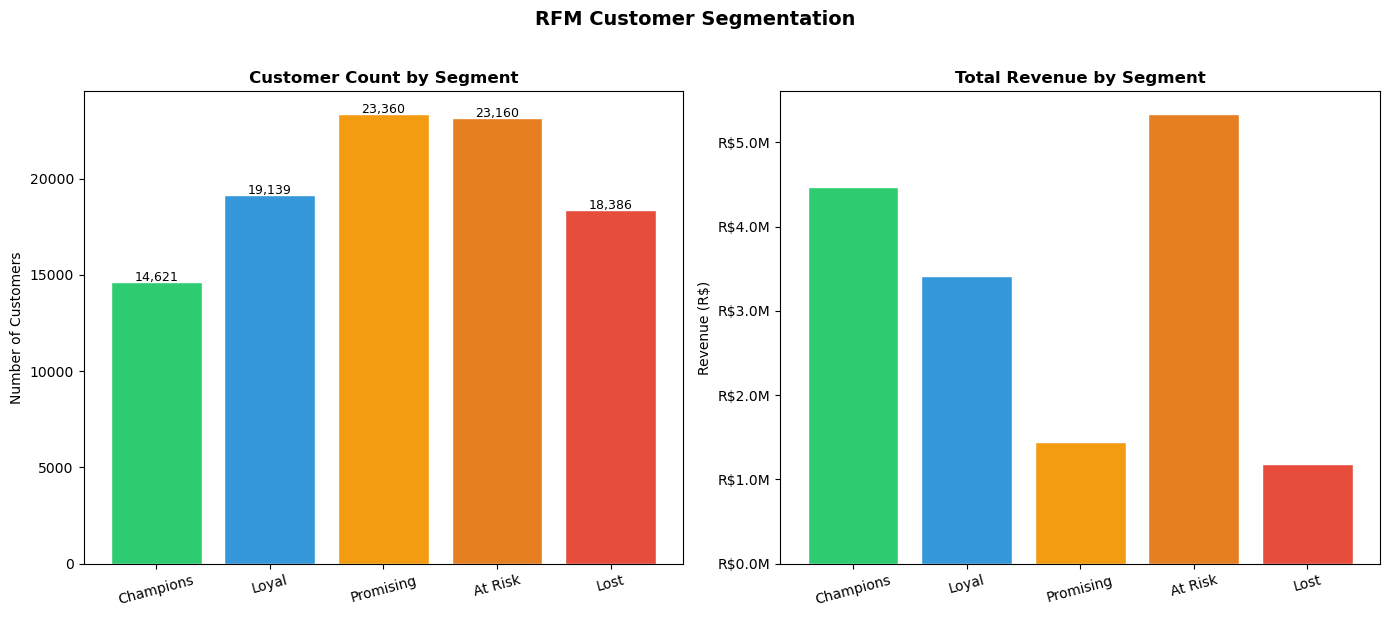

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

segment_order = ['Champions', 'Loyal', 'Promising', 'At Risk', 'Lost']
colors = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c']
color_map = dict(zip(segment_order, colors))

counts = rfm['segment'].value_counts().reindex(segment_order).fillna(0)
ax1.bar(counts.index, counts.values,
        color=[color_map[s] for s in counts.index], edgecolor='white')
ax1.set_title('Customer Count by Segment', fontweight='bold')
ax1.set_ylabel('Number of Customers')
ax1.tick_params(axis='x', rotation=15)
for i, v in enumerate(counts.values):
    ax1.text(i, v + 50, f'{int(v):,}', ha='center', fontsize=9)

rev = segment_profile['total_revenue'].reindex(segment_order).fillna(0)
ax2.bar(rev.index, rev.values,
        color=[color_map[s] for s in rev.index], edgecolor='white')
ax2.set_title('Total Revenue by Segment', fontweight='bold')
ax2.set_ylabel('Revenue (R$)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax2.tick_params(axis='x', rotation=15)

plt.suptitle('RFM Customer Segmentation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rfm_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

## Business Recommendation

**Finding:** Champions and Loyal customers represent a small share of the customer base but contribute disproportionately to total revenue. The At Risk and Lost segments represent customers who previously purchased but have not returned — a recoverable revenue opportunity.

**Recommendations:**
1. **Retain Champions** — enrol in a VIP programme with free shipping or early access to new sellers. Cost of retention is far lower than acquisition.
2. **Re-engage At Risk customers** — targeted discount campaign (10–15% off) sent within 30 days of their last purchase anniversary. Focus on their previously purchased categories.
3. **Convert Promising customers** — these customers purchased recently but infrequently. A follow-up email with complementary product recommendations within 2 weeks of purchase could drive a second order.